In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [37]:
import os

path = r"C:\Users\saksh\OneDrive\Documents\GitHub\House-Price-Prediction-ML"

print(os.path.exists(path))
print(os.listdir(path))

True
['anaconda_projects', 'app.py', 'data', 'models', 'notebooks', 'requirements.txt']


In [39]:
import os

path = r"C:\Users\saksh\OneDrive\Documents\GitHub\House-Price-Prediction-ML"

print(os.listdir(path))

['anaconda_projects', 'app.py', 'data', 'models', 'notebooks', 'requirements.txt']


In [41]:
import os

data_path = r"C:\Users\saksh\OneDrive\Documents\GitHub\House-Price-Prediction-ML\data"

print(os.path.exists(data_path))
print(os.listdir(data_path))

True
['Housing.csv']


In [45]:
df = pd.read_csv(
    r"C:\Users\saksh\OneDrive\Documents\GitHub\House-Price-Prediction-ML\data\Housing.csv"
)

In [47]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [49]:
df.shape

(545, 13)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [53]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [55]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [57]:
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

In [59]:
df['mainroad'] = df['mainroad'].fillna(df['mainroad'].mode()[0])

In [61]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [63]:
df.duplicated().sum()

0

In [65]:
df = df.drop_duplicates()

In [67]:
df.shape

(545, 13)

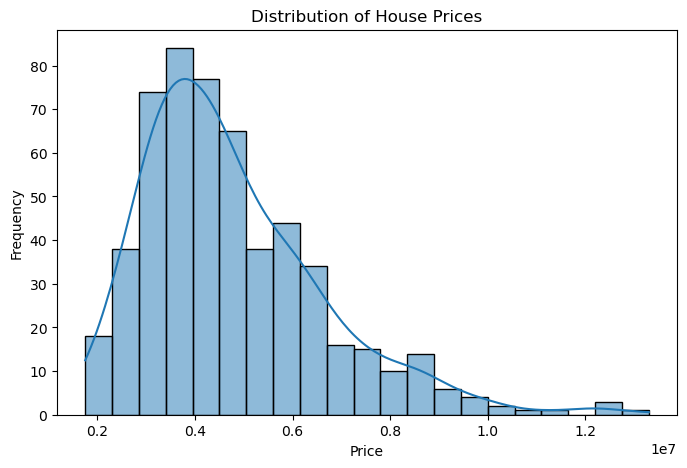

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

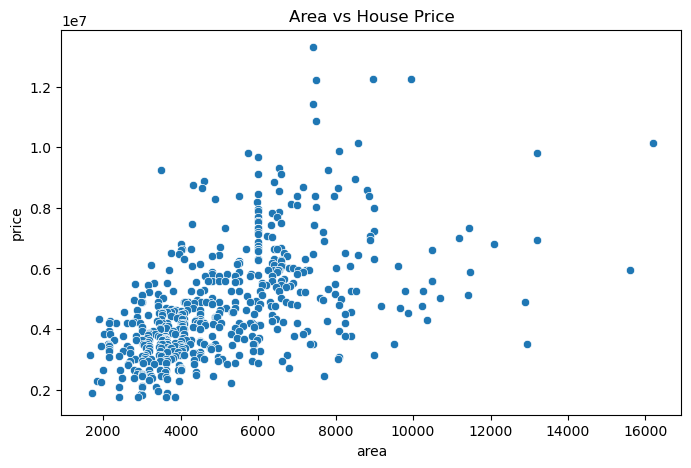

In [70]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='area',
    y='price'
)

plt.title("Area vs House Price")

plt.show()

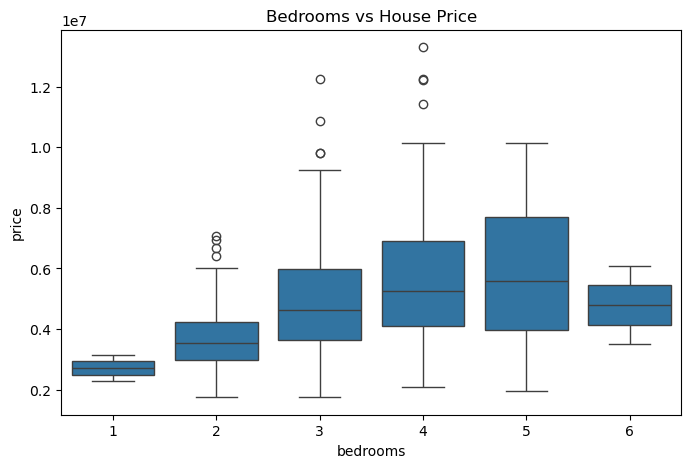

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='bedrooms',
    y='price'
)

plt.title("Bedrooms vs House Price")

plt.show()

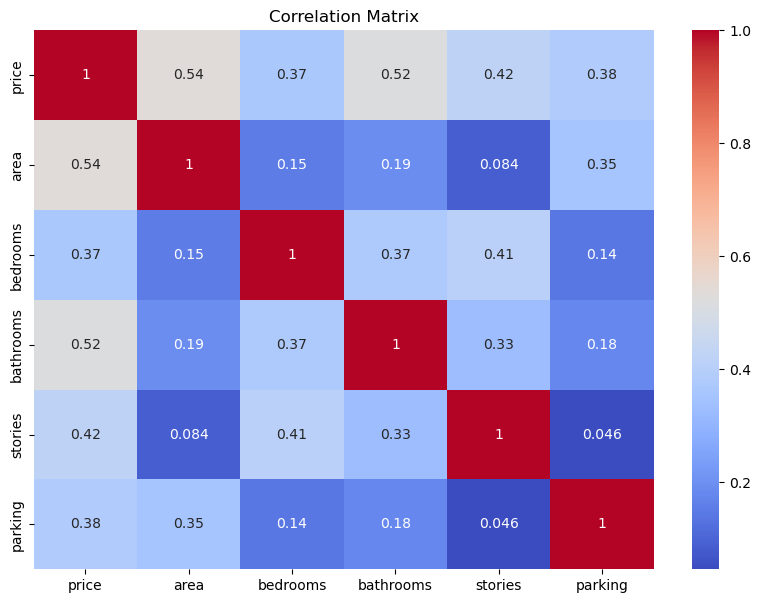

In [74]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [214]:
df['Bedrooms_per_area'] = df['bedrooms'] / df['area']

In [216]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [274]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,Price_per_area,Bedrooms_per_area,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1792.452830,0.000539,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,1367.187500,0.000446,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,1229.919679,0.000301,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,1628.666667,0.000533,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,1537.735849,0.000539,True,True,True,False,True,False,False,False


In [220]:
X = df_encoded.drop('price', axis=1)

y = df_encoded['price']

In [352]:
X = df_encoded.drop(
    ['price', 'Price_per_area'],
    axis=1
)

y = df_encoded['price']

In [354]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [356]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [357]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 1019552.5217125383
RMSE: 1394397.0339169311
R²: 0.6153296930443022


In [358]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [359]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [364]:
lr_pred = lr_model.predict(X_test)

In [366]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

In [368]:
print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression
MAE: 986563.0035564869
RMSE: 1345326.654298234
R²: 0.6419272621507712


In [370]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [372]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)

Ridge Regression
MAE: 970245.6759951375
RMSE: 1325320.4401656997
R²: 0.6524978022837837


In [374]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [375]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 1019552.5217125383
RMSE: 1394397.0339169311
R²: 0.6153296930443022


In [376]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Random Forest'
    ],
    'MAE': [
        lr_mae,
        ridge_mae,
        rf_mae
    ],
    'RMSE': [
        lr_rmse,
        ridge_rmse,
        rf_rmse
    ],
    'R2 Score': [
        lr_r2,
        ridge_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.865630e+05,1.345327e+06,0.641927
1,Ridge Regression,9.702457e+05,1.325320e+06,0.652498
2,Random Forest,1.019553e+06,1.394397e+06,0.615330


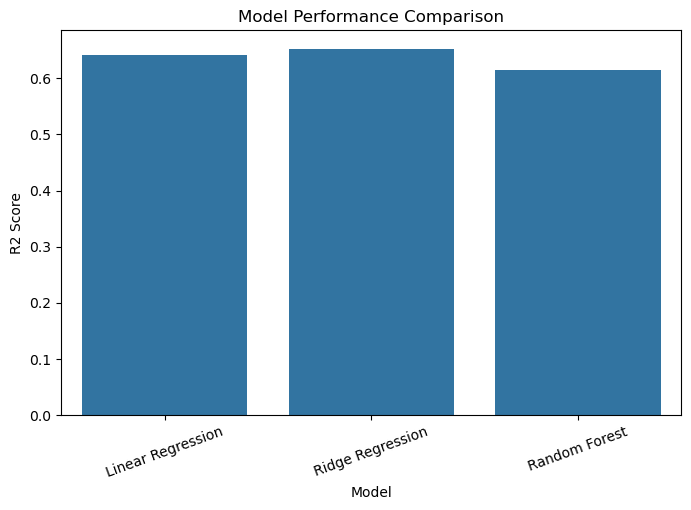

In [377]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title("Model Performance Comparison")
plt.xticks(rotation=20)

plt.show()

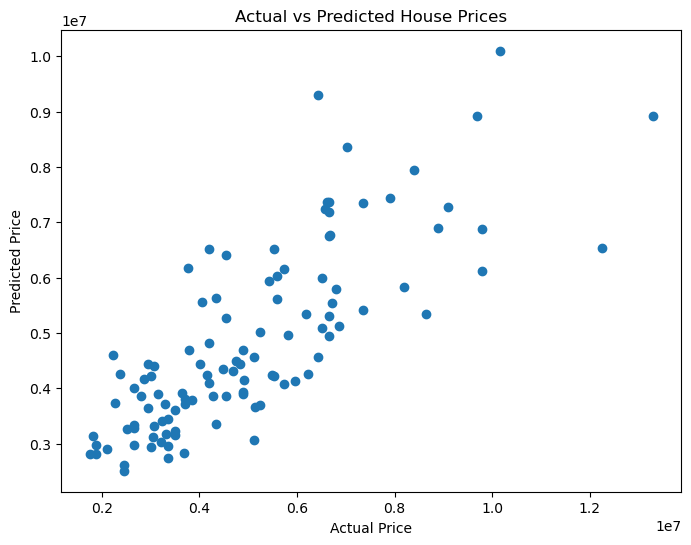

In [381]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [383]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

In [384]:
importance.head(10)

area                            0.440943
bathrooms                       0.149639
Bedrooms_per_area               0.078675
airconditioning_yes             0.057040
stories                         0.050790
parking                         0.050065
furnishingstatus_unfurnished    0.035276
basement_yes                    0.030005
bedrooms                        0.028203
prefarea_yes                    0.025945
dtype: float64

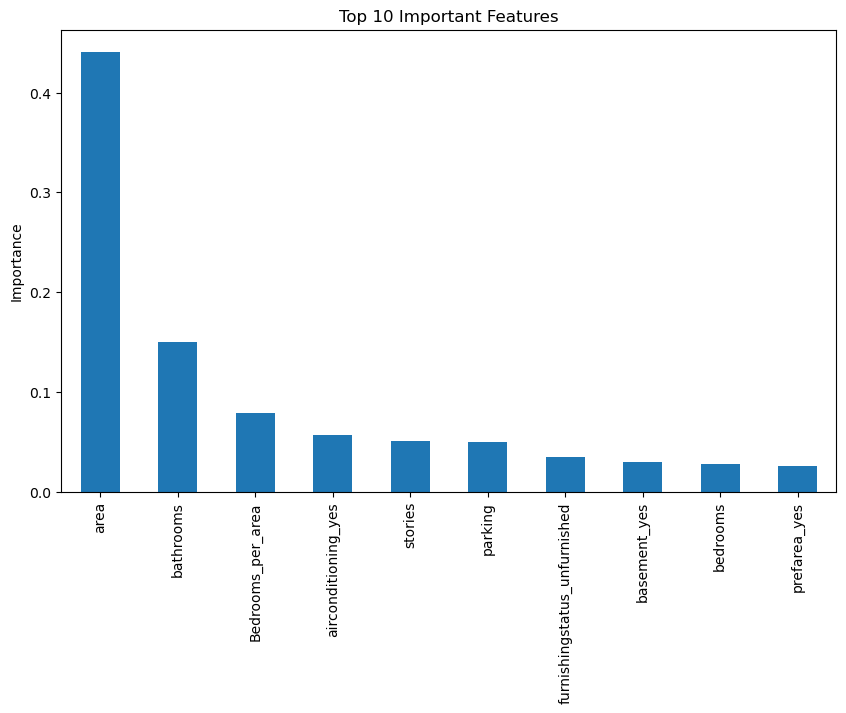

In [385]:
plt.figure(figsize=(10,6))

importance.head(10).plot(kind='bar')

plt.title("Top 10 Important Features")

plt.ylabel("Importance")

plt.show()

In [390]:
import joblib

joblib.dump(rf_model, "house_price_model.pkl")

['house_price_model.pkl']

In [392]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [394]:
import joblib

In [396]:
joblib.dump(rf_model, "house_price_model.pkl")

['house_price_model.pkl']

In [398]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [400]:
loaded_model = joblib.load("house_price_model.pkl")

In [402]:
loaded_columns = joblib.load("model_columns.pkl")

In [404]:
print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [406]:
print(loaded_columns)

['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'Bedrooms_per_area', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [414]:
import joblib

loaded_model = joblib.load("house_price_model.pkl")
loaded_columns = joblib.load("model_columns.pkl")

print(type(loaded_model))
print(loaded_columns)

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'Bedrooms_per_area', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [336]:
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'Price_per_area', 'Bedrooms_per_area']


In [410]:
print(X.columns.tolist())

['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'Bedrooms_per_area', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [412]:
import joblib

joblib.dump(
    rf_model,
    "house_price_model.pkl"
)

['house_price_model.pkl']

In [344]:
joblib.dump(
    X.columns.tolist(),
    "model_columns.pkl"
)

['model_columns.pkl']

In [350]:
print(X.columns.tolist())

['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'Bedrooms_per_area', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [416]:
import joblib

joblib.dump(
    rf_model,
    "house_price_model.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "model_columns.pkl"
)

print("Model and model columns saved successfully!")

Model and model columns saved successfully!


In [418]:
import joblib

print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [420]:
joblib.dump(
    rf_model,
    "../models/house_price_model.pkl"
)

print("✅ Correct Random Forest model saved!")

✅ Correct Random Forest model saved!


In [422]:
test_model = joblib.load("../models/house_price_model.pkl")

print(type(test_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [424]:
print(type(test_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
